# Cat Diffusion — Métricas y Comparativa de Fases

Analiza los modelos de difusión entrenados sobre el dataset de gatos 64×64.

### Secciones
1. **Curva FID vs epoch** — evolución del FID a lo largo de Phase 1 y Phase 2 (doble descenso)
2. **Comparativa visual 5×5** — VP-Exponencial final vs VP-Coseno final
3. **Métricas finales** — FID · BPD · IS para Phase 1 final vs Phase 2 final


## Setup

In [157]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset
from torchvision.transforms import ToTensor

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'diffusion_lib').exists():
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

from diffusion_lib import (
    VPProcess, ExponentialSchedule, CosineSchedule,
    EulerMaruyamaSampler,
    UNetScoreModelColor, GenerativeDiffusionModel,
)
from diffusion_lib.metrics.fid_is import compute_fid, compute_is
from diffusion_lib.metrics.bpd import compute_bpd

device = 'mps'
print('Device:', device)

# ── Paths ──────────────────────────────────────────────────────────────────────
CAT_FOLDER        = PROJECT_DIR / 'otras_pruebas' / 'cat_AI_v2' / 'cats'
CKPT_DIR_EXP      = PROJECT_DIR / 'checkpoints_cats'           # VP-Exponencial (Phase 1 + 2)
CKPT_DIR_COS      = PROJECT_DIR / 'checkpoints_coseno'         # VP-Coseno (Phase 1 + 2)
FIGURAS_DIR       = PROJECT_DIR / 'Figuras'
FIGURAS_DIR.mkdir(exist_ok=True)

# ── Hiperparámetros ────────────────────────────────────────────────────────────
IMG_SHAPE = (3, 64, 64)

# FID evolution curve (por checkpoint — prioriza velocidad sobre precisión)
N_FID_CURVE    = 200   # imágenes generadas por checkpoint
N_STEPS_CURVE  = 500   # pasos de integración para la curva

# Métricas finales (más precisas, solo para los checkpoints finales)
N_FID_FINAL    = 400   # N=200 da std ~±5-10 pts: suficiente para comparar modelos
N_STEPS_FINAL  = 1500

# BPD (costoso — subconjunto pequeño)
N_BPD          = 64
N_BPD_STEPS    = 50
BPD_BATCH      = 16


Device: mps


In [158]:
class CatFolderDataset(Dataset):
    def __init__(self, folder_path):
        paths = sorted(Path(folder_path).glob('*.jpg'))
        transform = ToTensor()
        print(f'Cargando {len(paths)} imágenes...')
        self.images = [transform(Image.open(p).convert('RGB')) for p in paths]
    def __len__(self): return len(self.images)
    def __getitem__(self, idx): return self.images[idx], 0

full_dataset = CatFolderDataset(CAT_FOLDER)
print(f'Total: {len(full_dataset)} imágenes  |  shape: {full_dataset[0][0].shape}')

rng = np.random.default_rng(42)
idx_all = rng.choice(len(full_dataset), size=N_FID_FINAL, replace=False)

# Referencia para la curva FID (mismo N que las generadas por checkpoint)
x_real_curve = torch.stack([full_dataset[int(i)][0] for i in idx_all[:N_FID_CURVE]])

# Referencia para las métricas finales (más imágenes → estimador más preciso)
x_real_final = torch.stack([full_dataset[int(i)][0] for i in idx_all])

x_bpd = x_real_final[:N_BPD]
print(f'Real (curva):   {x_real_curve.shape}')
print(f'Real (final):   {x_real_final.shape}')
print(f'Real (BPD):     {x_bpd.shape}')


Cargando 15747 imágenes...
Total: 15747 imágenes  |  shape: torch.Size([3, 64, 64])
Real (curva):   torch.Size([200, 3, 64, 64])
Real (final):   torch.Size([400, 3, 64, 64])
Real (BPD):     torch.Size([64, 3, 64, 64])


In [159]:
import sys
sys.path.insert(0, str(PROJECT_DIR / 'otras_pruebas' / 'cat_AI_v2'))
from score_net import ScoreNet

def load_model(ckpt_path: Path, sigma_t_fn):
    """Carga un score model desde un checkpoint .pth.
    - Elimina el prefijo 'module.' si el modelo fue guardado con DataParallel.
    - Intenta UNetScoreModelColor primero; si falla usa ScoreNet (legacy).
    """
    state = torch.load(ckpt_path, map_location=device, weights_only=True)
    # Quitar prefijo DataParallel si existe
    if any(k.startswith('module.') for k in state):
        state = {k[len('module.'):]: v for k, v in state.items()}
    for cls in [UNetScoreModelColor, ScoreNet]:
        try:
            m = cls(marginal_prob_std=sigma_t_fn).to(device)
            m.load_state_dict(state)
            m.eval()
            return m
        except RuntimeError:
            continue
    raise RuntimeError(f"No se pudo cargar {ckpt_path.name} en ninguna arquitectura conocida.")

def epoch_from_name(p: Path) -> int:
    """Extrae el número de época del nombre del checkpoint."""
    import re
    m = re.search(r'ep(\d+)', p.stem)
    return int(m.group(1)) if m else 0


---
## 1 · Curva FID vs epoch — ¿Double descent?

Se evalúa el FID en cada uno de los checkpoints logarítmicos guardados durante el entrenamiento, formando una curva continua de 30 puntos:
- **Tramo azul** (ep 1–1500): Phase 1, lr = 1e-3, entrenamiento desde cero
- **Tramo naranja** (ep 1501–3000): Phase 2, lr = 1e-4, fine-tuning

Si el FID vuelve a descender al comienzo de Phase 2 tras haberse estabilizado en Phase 1, estaríamos ante el fenómeno de *double descent*.


In [160]:
def fid_curve_for_phase(ckpt_dir: Path, phase: int, process,
                         epoch_offset: int = 0,
                         min_epoch: int = 0) -> tuple[list, list]:
    """
    Calcula el FID para cada checkpoint de una fase.
    min_epoch: ignora checkpoints con época < min_epoch (útil para saltarse
               los primeros pasos de Phase 2, donde el modelo apenas ha cambiado).
    """
    pattern = f'*phase{phase}*.pth'
    ckpts   = sorted(ckpt_dir.glob(pattern), key=epoch_from_name)
    ckpts   = [c for c in ckpts if epoch_from_name(c) >= min_epoch]
    if not ckpts:
        print(f'  [!] No se encontraron checkpoints para phase {phase} en {ckpt_dir}')
        return [], []

    epochs, fids = [], []
    for ckpt in ckpts:
        ep = epoch_from_name(ckpt)
        print(f'  ep{ep:4d} ...', end=' ', flush=True)
        model = load_model(ckpt, process.sigma_t)
        gm    = GenerativeDiffusionModel(process, EulerMaruyamaSampler(), model, device)
        fake  = gm.sample(n_images=N_FID_CURVE, img_shape=IMG_SHAPE,
                           n_steps=N_STEPS_CURVE).cpu().clamp(0, 1)
        fid   = compute_fid(x_real_curve, fake, device=device)
        epochs.append(ep + epoch_offset)
        fids.append(fid)
        print(f'FID = {fid:.1f}')
        del model, gm, fake
        if str(device) == 'cuda':
            torch.cuda.empty_cache()

    return epochs, fids


In [161]:
proc_exp = VPProcess(schedule=ExponentialSchedule())

# print('=== VP-Exp | Phase 1 ===')
# ep1_exp, fid1_exp = fid_curve_for_phase(CKPT_DIR_EXP, phase=1, process=proc_exp,
#                                          epoch_offset=0)

# print('\n=== VP-Exp | Phase 2 (desde ep65) ===')
# ep2_exp, fid2_exp = fid_curve_for_phase(CKPT_DIR_EXP, phase=2, process=proc_exp,
#                                          epoch_offset=1500, min_epoch=65)

In [162]:
# fig, ax = plt.subplots(figsize=(10, 5))

# if ep1_exp:
#     ax.plot(ep1_exp, fid1_exp, 'o-', color='steelblue',
#             label='Phase 1  (lr=1e-3)', lw=2, ms=6)

# if ep2_exp:
#     ax.plot(ep2_exp, fid2_exp, 's-', color='darkorange',
#             label='Phase 2  (lr=1e-4)', lw=2, ms=6)

# if ep1_exp and ep2_exp:
#     ax.axvline(1500, color='gray', ls='--', lw=1.5, label='Inicio Phase 2')

# ax.set_xlabel('Época (acumulada)', fontsize=12)
# ax.set_ylabel('FID ↓', fontsize=12)
# ax.set_title('VP-Exponencial — Evolución del FID en test (Gatos 64×64)', fontsize=13)
# ax.legend(fontsize=11)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# fig.savefig(FIGURAS_DIR / 'cats_fid_curve.png', bbox_inches='tight', dpi=150)
# plt.show()
# print('Figura guardada → Figuras/cats_fid_curve.png')

---
## 2 · Comparativa visual 5×5 — VP-Exp vs VP-Coseno

Rejillas de 25 muestras generadas con los checkpoints finales de cada proceso.
Si los checkpoints de VP-Coseno aún no existen, se compara Phase 1 vs Phase 2 (VP-Exp).


In [163]:
from torchvision.utils import make_grid
from diffusion_lib import VEProcess

proc_ve = VEProcess()

MODELS_VIS = {
    'VP-Exp final': {
        'ckpt': CKPT_DIR_EXP / 'cat64_VP-Exp_phase2_lr1e-04_ep1500.pth',
        'proc': VPProcess(schedule=ExponentialSchedule()),
    },
    'VE-Brownian final': {
        'ckpt': PROJECT_DIR / 'otras_pruebas' / 'cat_AI_v2' / 'cats64_2000_checkpoints' / 'cat64_diffusion_2000_epochs.pth',
        'proc': proc_ve,
    },
}

N_VIS = 25  # 5x5

vis_images = {}
for label, cfg in MODELS_VIS.items():
    print(f'Generando rejilla 5x5 - {label}...', end=' ', flush=True)
    m    = load_model(cfg['ckpt'], cfg['proc'].sigma_t)
    gm   = GenerativeDiffusionModel(cfg['proc'], EulerMaruyamaSampler(), m, device)
    n_steps_vis = 1500 if 'VP' in label else 1000
    imgs = gm.sample(n_images=N_VIS, img_shape=IMG_SHAPE,
                     n_steps=n_steps_vis).cpu().clamp(0, 1)
    vis_images[label] = imgs
    print('done')
    del m, gm
    if str(device) == 'cuda':
        torch.cuda.empty_cache()

Generando rejilla 5x5 - VP-Exp final... done
Generando rejilla 5x5 - VE-Brownian final... done


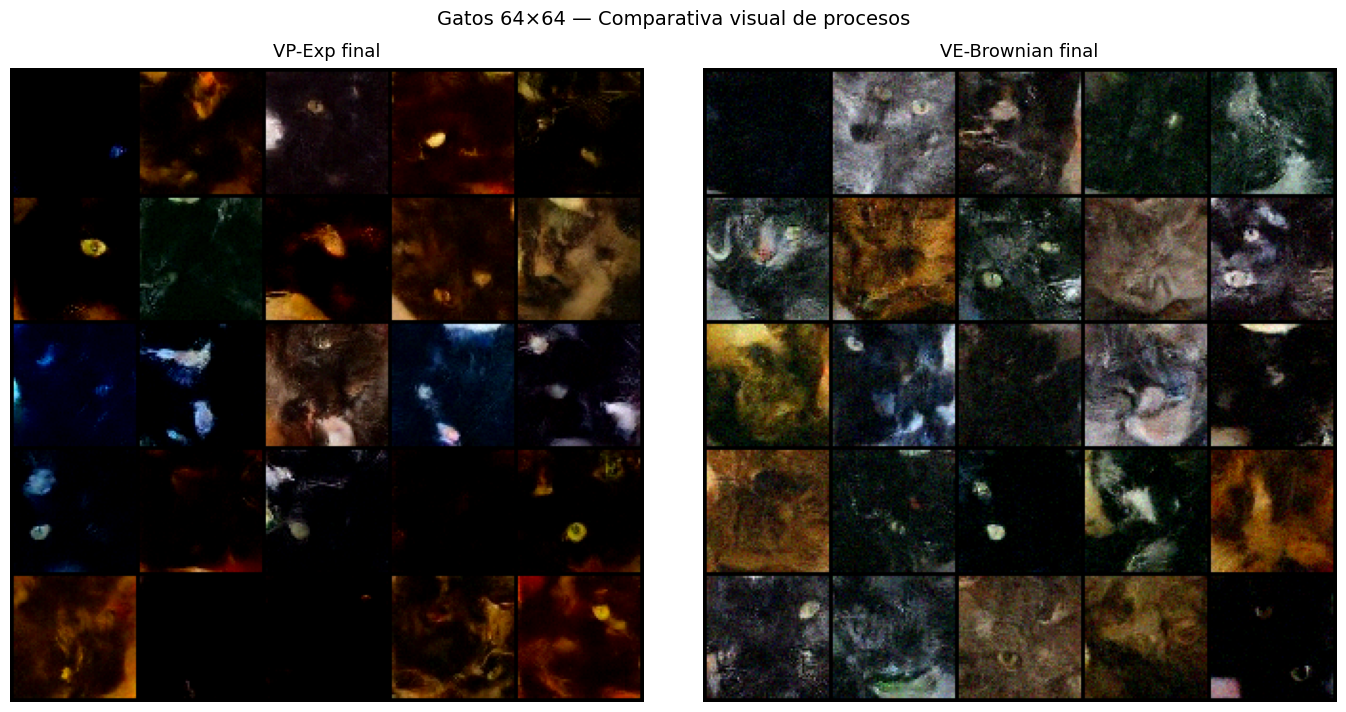

Figura guardada → Figuras/cats_generation_comparison.png


In [164]:
n = len(vis_images)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
if n == 1:
    axes = [axes]

for ax, (label, imgs) in zip(axes, vis_images.items()):
    grid = make_grid(imgs, nrow=5, padding=2).permute(1, 2, 0).numpy()
    ax.imshow(grid)
    ax.set_title(label, fontsize=13, pad=8)
    ax.axis('off')

plt.suptitle('Gatos 64×64 — Comparativa visual de procesos', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(FIGURAS_DIR / 'cats_generation_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura guardada → Figuras/cats_generation_comparison.png')

---
## 3 · Métricas finales — Phase 1 vs Phase 2

FID, BPD e IS sobre los checkpoints finales (ep1500) de VP-Exponencial.


In [165]:
FINAL_CKPTS = {
    'Phase 1  (lr=1e-3)': CKPT_DIR_EXP / 'cat64_VP-Exp_phase1_lr1e-03_ep1500.pth',
    'Phase 2  (lr=1e-4)': CKPT_DIR_EXP / 'cat64_VP-Exp_phase2_lr1e-04_ep1500.pth',
}

final_models = {}
for name, path in FINAL_CKPTS.items():
    final_models[name] = load_model(path, proc_exp.sigma_t)
    print(f'[OK] {name}')

[OK] Phase 1  (lr=1e-3)
[OK] Phase 2  (lr=1e-4)


### FID

In [166]:
fid_scores = {}
for name, model in final_models.items():
    print(f'FID [{name}]: generando {N_FID_FINAL} imágenes...', end=' ', flush=True)
    gm   = GenerativeDiffusionModel(proc_exp, EulerMaruyamaSampler(), model, device)
    fake = gm.sample(n_images=N_FID_FINAL, img_shape=IMG_SHAPE,
                     n_steps=N_STEPS_FINAL).cpu().clamp(0, 1)
    fid  = compute_fid(x_real_final, fake, device=device)
    fid_scores[name] = fid
    print(f'FID = {fid:.2f}')
    del gm, fake
    # if device.type == 'cuda':
    #     torch.cuda.empty_cache()

FID [Phase 1  (lr=1e-3)]: generando 400 imágenes... FID = 246.59
FID [Phase 2  (lr=1e-4)]: generando 400 imágenes... FID = 251.99


### BPD

In [167]:
bpd_scores = {}
for name, model in final_models.items():
    bpd_list = []
    for start in range(0, len(x_bpd), BPD_BATCH):
        batch = x_bpd[start:start + BPD_BATCH].to(device)
        bpd_batch = compute_bpd(model, proc_exp, batch,
                                n_steps=N_BPD_STEPS, n_hutchinson=1,
                                T=proc_exp.T)
        bpd_list.append(bpd_batch.cpu())
    mean_bpd = torch.cat(bpd_list).mean().item()
    bpd_scores[name] = mean_bpd
    print(f'BPD [{name}]: {mean_bpd:.4f}')

BPD [Phase 1  (lr=1e-3)]: -11.5094
BPD [Phase 2  (lr=1e-4)]: -11.2567


### IS

In [168]:
is_scores = {}
for name, model in final_models.items():
    gm   = GenerativeDiffusionModel(proc_exp, EulerMaruyamaSampler(), model, device)
    imgs = gm.sample(n_images=100, img_shape=IMG_SHAPE,
                     n_steps=N_STEPS_FINAL).cpu().clamp(0, 1)
    is_mean, is_std = compute_is(imgs, device=device)
    is_scores[name] = (is_mean, is_std)
    print(f'IS [{name}]: {is_mean:.3f} ± {is_std:.3f}')
    del gm, imgs
    # if device.type == 'cuda':
    #     torch.cuda.empty_cache()

IS [Phase 1  (lr=1e-3)]: 2.197 ± 0.161
IS [Phase 2  (lr=1e-4)]: 2.051 ± 0.167


### Resumen

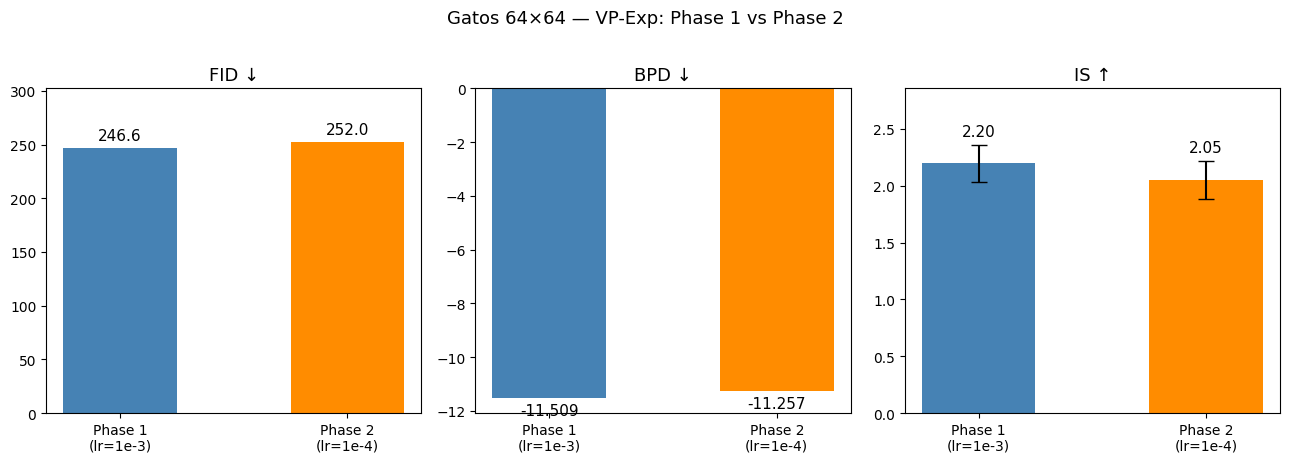


=== Resumen final ===
Modelo                          FID       BPD              IS
-----------------------------------------------------------------
Phase 1  (lr=1e-3)           246.59  -11.5094   2.197 ± 0.161
Phase 2  (lr=1e-4)           251.99  -11.2567   2.051 ± 0.167

Figura guardada → Figuras/cats_metrics_comparison.png


In [169]:
names       = list(final_models.keys())
name_labels = ['Phase 1\n(lr=1e-3)', 'Phase 2\n(lr=1e-4)']

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

# FID
ax = axes[0]
bars = ax.bar(name_labels, [fid_scores[n] for n in names],
              color=['steelblue', 'darkorange'], width=0.5)
ax.bar_label(bars, fmt='%.1f', padding=4, fontsize=11)
ax.set_title('FID ↓', fontsize=13)
ax.set_ylim(0, max(fid_scores.values()) * 1.2)

# BPD
ax = axes[1]
bars = ax.bar(name_labels, [bpd_scores[n] for n in names],
              color=['steelblue', 'darkorange'], width=0.5)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=11)
ax.set_title('BPD ↓', fontsize=13)

# IS
ax = axes[2]
means = [is_scores[n][0] for n in names]
stds  = [is_scores[n][1] for n in names]
bars  = ax.bar(name_labels, means, yerr=stds,
               color=['steelblue', 'darkorange'], width=0.5, capsize=6)
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=11)
ax.set_title('IS ↑', fontsize=13)
ax.set_ylim(0, max(means) * 1.3)

plt.suptitle('Gatos 64×64 — VP-Exp: Phase 1 vs Phase 2', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(FIGURAS_DIR / 'cats_metrics_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n=== Resumen final ===')
print(f'{"Modelo":<25}  {"FID":>8}  {"BPD":>8}  {"IS":>14}')
print('-' * 65)
for n in names:
    print(f'{n:<25}  {fid_scores[n]:>8.2f}  {bpd_scores[n]:>8.4f}  '
          f'{is_scores[n][0]:>6.3f} ± {is_scores[n][1]:.3f}')
print('\nFigura guardada → Figuras/cats_metrics_comparison.png')
